# Classification

## Binary classification with Logistic Regression

In the following example, we'll use Logistic Regression (we'll go into detail about this algorithm in the next lecture) to classify breast tumors as malignant or benign based on the physical properties of the tumor (e.g. size, shape, texture).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV


In [2]:

# Load the breast cancer dataset
bc_df, y = load_breast_cancer(return_X_y=True, as_frame=True)

# We'll uncomment the line below the second time through
# bc_df = bc_df[['worst texture']]

# The original dataset maps 0=malignant, 1=benign. This feels backwards to me, so I swap 0 and 1
y = 1-y 
display(bc_df.describe())
display(y.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


count    569.000000
mean       0.372583
std        0.483918
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

First, we prepare the data.

Notice that the numerical values of the features range from numbers in the 1000s down to numbers less than 1. It will be important to scale the features.

In [3]:

X_train, X_test, y_train, y_test = train_test_split(bc_df, y, test_size= 0.2)

sc = StandardScaler()
Z_train = sc.fit_transform(X_train)
Z_test = sc.transform(X_test)

Now we create and fit the model.

In [13]:
Cs = np.logspace(-3, 3, 25)

logreg = LogisticRegressionCV(Cs = Cs, penalty = 'l1', 
                              solver = 'liblinear',
                              max_iter = 1000)
logreg.fit(Z_train, y_train)

/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converg

,Cs,array([1.0000...00000000e+03])
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l1'
,scoring,None
,solver,'liblinear'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [5]:
logreg.__dict__

{'Cs': array([1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
        1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
        1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
        1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
        1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
        1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
        1.00000000e+03]),
 'fit_intercept': True,
 'cv': None,
 'dual': False,
 'penalty': 'l1',
 'scoring': None,
 'tol': 0.0001,
 'max_iter': 100,
 'class_weight': None,
 'n_jobs': None,
 'verbose': 0,
 'solver': 'liblinear',
 'refit': True,
 'intercept_scaling': 1.0,
 'multi_class': 'deprecated',
 'random_state': None,
 'l1_ratios': None,
 'n_features_in_': 30,
 'classes_': array([0, 1]),
 'Cs_': array([1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
        1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
        1.000000

### Inspecting Feature Importance

Below, I rank the features based on their absolute value. BIG numbers (either positive or negative) correspond to important features, just like Linear Regression!

In [6]:
feature_names = list(bc_df.columns)

coefs = logreg.coef_.flatten()
coefs

idx = np.argsort(np.abs(coefs))

for i in idx[::-1]:
    print(f'{feature_names[i]:<30}\t{coefs[i]:+0.2f}')

worst radius                  	+3.70
radius error                  	+2.65
worst texture                 	+1.52
worst concave points          	+1.28
worst concavity               	+0.92
mean concave points           	+0.80
worst smoothness              	+0.74
worst area                    	+0.57
compactness error             	-0.53
worst symmetry                	+0.40
texture error                 	-0.28
fractal dimension error       	-0.26
mean texture                  	+0.19
smoothness error              	+0.11
mean smoothness               	+0.00
mean compactness              	+0.00
mean area                     	+0.00
mean symmetry                 	+0.00
mean concavity                	+0.00
mean perimeter                	+0.00
worst fractal dimension       	+0.00
mean fractal dimension        	+0.00
perimeter error               	+0.00
area error                    	+0.00
concavity error               	+0.00
concave points error          	+0.00
symmetry error                	+0.00
w

In [7]:

y_pred_train = logreg.predict(Z_train)
y_pred_test = logreg.predict(Z_test)

y_prob_train = logreg.predict_proba(Z_train)
y_prob_test = logreg.predict_proba(Z_test)

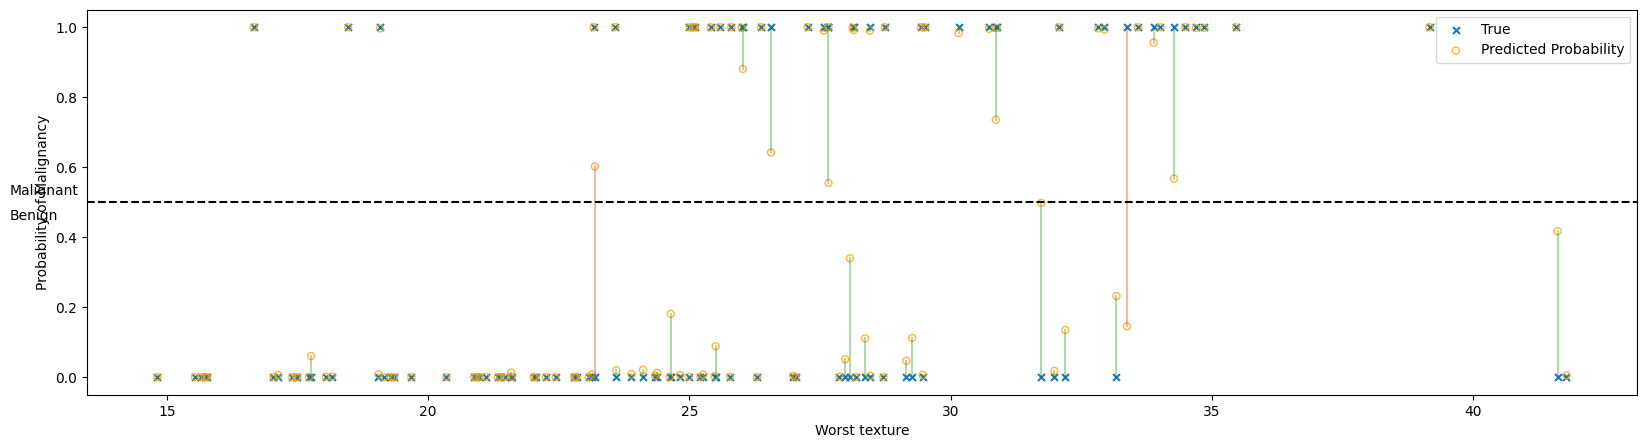

In [8]:

x = X_test['worst texture'].to_numpy().reshape(-1,1)

plt.subplots(1,1, figsize = (20, 5))

plt.scatter(x, y_test, label = 'True',
            s = 25, marker = 'x')

plt.scatter(x, y_prob_test[:,1], label = 'Predicted Probability', 
            s = 25, 
            alpha = 0.8, marker = 'o', ec = 'orange', facecolor = 'none')

idx_T = (y_test == y_pred_test)
plt.plot(np.column_stack((x[idx_T], x[idx_T])).T, np.column_stack((y_test[idx_T], y_prob_test[idx_T,1])).T, 'g-',
            alpha = 0.3, marker = 'none')

idx_F = (y_test != y_pred_test)
plt.plot(np.column_stack((x[idx_F], x[idx_F])).T, np.column_stack((y_test[idx_F], y_prob_test[idx_F,1])).T, 'r-',
            alpha = 0.3, marker = 'none')

plt.axhline(0.5, c = 'k', ls = '--')
plt.text(12, 0.52, 'Malignant')
plt.text(12, 0.45, 'Benign')

plt.legend()
plt.xlabel('Worst texture')
plt.ylabel('Probability of Malignancy')
plt.show()

In the figure above:
 - Each 'x' represents the true classification of a single tumor, benign at the bottom and malignant at the top. 
 - Each 'o' is the probability that the logistic regressor predicted given the feature set. A probability greater than 50% will be classified as malignant and less than 50% as benign.

The predictiction and true value are connected with a line to help show correspondences, with green lines being correct predictions and red lines showing incorrect predictions. Notice that all the red lines cross the 50% threshold line.

## Model Assessment

### Confusion Matrix

The *Confusion Matrix* is a graphical representation of the predictions a classifier has made on the data set. The confusion matrix is an nxn grid where n is the number of categories; for binary classification, the confusion matrix is always 2x2.

Let's look at the confusion matrix for the breast tumor classification above.

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, precision_recall_curve, PrecisionRecallDisplay


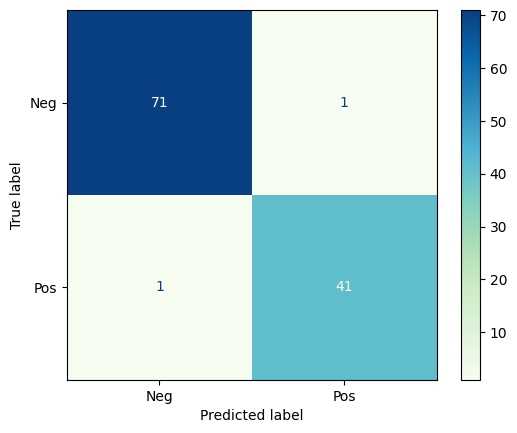

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, 
                                        # normalize = 'true',
                                        # display_labels = ['Benign', 'Malignant'],
                                        display_labels = ['Neg', 'Pos'],
                                        cmap = 'GnBu'
                                        )
plt.show()

In [11]:

cr = classification_report(y_test, y_pred_test, target_names = ['Benign', 'Malignant'])
print(cr)

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Precision-Recall Tradeoff

Precision and Recall are often at odds with eachother. Imagine the logistic regression above, but we could change the threshold for designating a tumor as malignant or benign.
 - If we **raise the threshold** (e.g. only say the tumor is malignant if the probability is greater than 90%) we'll label fewer cases as malignant. We'll have missed some malignant tumors, but we'll be more confident in the ones we detected. This **increases precision** but **decreases recall**.
 - If we **lower the threshold** (e.g. say the tumor is malignant if the probability is greater than 10%) we'll label more cases as malignant. We're more likely to catch most of the positive cases, but we'll also be misclassifying many benign tumors as malignant. This **increases recall** but **decreases precision**.

The Precision-Recall curve calculates the precision and recall for different levels of threshold from 0-1.

/Users/eatai/.pyenv/versions/3.13.1/envs/datascience/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(


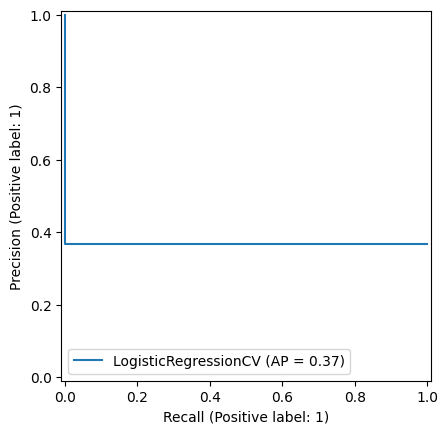

In [12]:
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test)
plt.show()